In [77]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [78]:
research.set_seed(42)

In [79]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [80]:
# Trading pair symbol
sym = 'BTCUSDT'
# time horizon of time series (time interval)
time_interval = '8h'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps 
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [81]:
import binance
print(binance.__file__)
print([x for x in dir(binance) if "download" in x.lower()])

c:\Users\micha\Documents\Code\school\cpp\classes\spring-2026\mat_4860\quant_trading_strategy\ML-Systematic-Trading-Engine\binance.py
['download_and_unzip', 'download_date_range', 'download_ohlc_timeseries', 'download_timeseries', 'download_trades']


In [82]:
# Data is already downloaded and processed into 8h OHLC CSV
# binance.download_date_range(sym, start_date, end_date)


In [84]:
ts = pl.read_csv(f"{sym}_{time_interval}_ohlc.csv", try_parse_dates=True).sort('datetime')
ts


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,94696.4
2025-05-05 08:00:00,94696.4,94726.8,93559.6,93726.0
2025-05-05 16:00:00,93726.0,95165.1,93705.3,94696.7
2025-05-06 00:00:00,94696.7,94893.3,93961.0,94350.0
2025-05-06 08:00:00,94350.0,94697.2,93327.0,94513.2
…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8


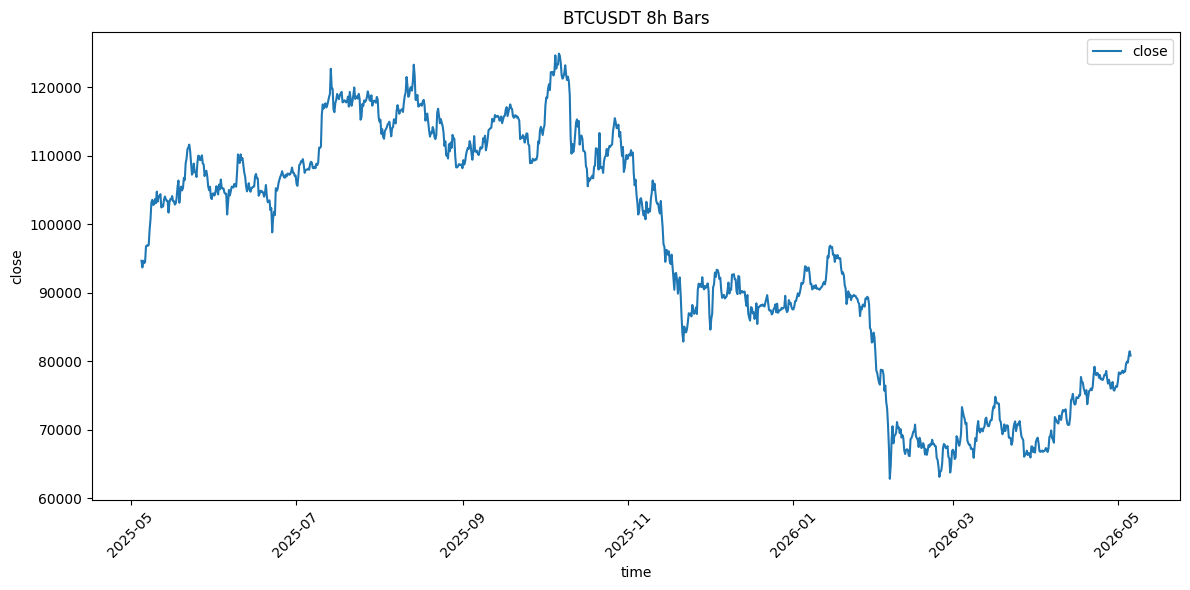

In [85]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [86]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [87]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [88]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [89]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,94696.4,null
2025-05-05 08:00:00,94696.4,94726.8,93559.6,93726.0,-0.0103
2025-05-05 16:00:00,93726.0,95165.1,93705.3,94696.7,0.010304
2025-05-06 00:00:00,94696.7,94893.3,93961.0,94350.0,-0.003668
2025-05-06 08:00:00,94350.0,94697.2,93327.0,94513.2,0.001728
…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322


In [90]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,94696.4,null,null,null,null,null
2025-05-05 08:00:00,94696.4,94726.8,93559.6,93726.0,-0.0103,null,null,null,null
2025-05-05 16:00:00,93726.0,95165.1,93705.3,94696.7,0.010304,-0.0103,null,null,null
2025-05-06 00:00:00,94696.7,94893.3,93961.0,94350.0,-0.003668,0.010304,-0.0103,null,null
2025-05-06 08:00:00,94350.0,94697.2,93327.0,94513.2,0.001728,-0.003668,0.010304,-0.0103,null
…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,-0.004285
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,0.003933
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,-0.001224


In [91]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,94778.5,93445.1,94696.4,null,null,null,null,null
2025-05-05 08:00:00,94696.4,94726.8,93559.6,93726.0,-0.0103,null,null,null,null
2025-05-05 16:00:00,93726.0,95165.1,93705.3,94696.7,0.010304,-0.0103,null,null,null
2025-05-06 00:00:00,94696.7,94893.3,93961.0,94350.0,-0.003668,0.010304,-0.0103,null,null
2025-05-06 08:00:00,94350.0,94697.2,93327.0,94513.2,0.001728,-0.003668,0.010304,-0.0103,null
…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,-0.004285
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,0.003933
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,-0.001224


In [92]:
ts = ts.drop_nulls()

In [93]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [94]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [95]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [96]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

### Split by time

In [97]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [98]:
len(ts)

1093

In [99]:
int(len(ts) * test_size)

273

In [100]:
split_idx = int(len(ts) * (1-test_size))
split_idx

819

In [101]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [102]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-06 16:00:00,94513.2,96879.5,94145.4,96798.9,0.023896,0.001728,-0.003668,0.010304,-0.0103
2025-05-07 00:00:00,96798.9,97700.0,96153.2,96940.0,0.001457,0.023896,0.001728,-0.003668,0.010304
2025-05-07 08:00:00,96940.0,97446.8,96655.2,96889.0,-0.000526,0.001457,0.023896,0.001728,-0.003668
2025-05-07 16:00:00,96889.0,97363.8,95718.5,96988.4,0.001025,-0.000526,0.001457,0.023896,0.001728
2025-05-08 00:00:00,96988.4,99374.3,96831.5,99212.0,0.022668,0.001025,-0.000526,0.001457,0.023896
…,…,…,…,…,…,…,…,…,…
2026-02-02 00:00:00,76931.6,78111.0,74555.0,76612.6,-0.004154,-0.008185,-0.009712,-0.004916,-0.03203
2026-02-02 08:00:00,76612.6,79311.0,76576.7,78800.6,0.028159,-0.004154,-0.008185,-0.009712,-0.004916
2026-02-02 16:00:00,78800.5,79248.0,77843.2,78692.5,-0.001373,0.028159,-0.004154,-0.008185,-0.009712


In [103]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 16:00:00,78094.2,78101.5,72889.2,75732.4,-0.030708,-0.008362,0.000729,-0.001373,0.028159
2026-02-04 00:00:00,75732.4,76952.5,75420.0,76478.9,0.009809,-0.030708,-0.008362,0.000729,-0.001373
2026-02-04 08:00:00,76478.9,76568.0,73756.0,74107.0,-0.031505,0.009809,-0.030708,-0.008362,0.000729
2026-02-04 16:00:00,74107.0,74211.8,71838.0,73137.4,-0.01317,-0.031505,0.009809,-0.030708,-0.008362
2026-02-05 00:00:00,73137.5,73316.3,70085.3,70716.1,-0.033667,-0.01317,-0.031505,0.009809,-0.030708
…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,-0.004285
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,0.003933
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,-0.001224


In [104]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)


In [105]:
X_train

tensor([[ 1.7282e-03],
        [ 2.3896e-02],
        [ 1.4566e-03],
        [-5.2624e-04],
        [ 1.0254e-03],
        [ 2.2668e-02],
        [ 1.5193e-02],
        [ 2.4489e-02],
        [ 3.5711e-03],
        [-7.2124e-03],
        [ 8.6494e-04],
        [ 7.5466e-03],
        [-5.9867e-03],
        [ 1.6222e-02],
        [-1.4039e-02],
        [ 7.2812e-03],
        [-9.8964e-05],
        [ 3.3909e-03],
        [-1.8796e-02],
        [ 2.5105e-03],
        [-1.1229e-03],
        [ 9.7850e-03],
        [ 4.3223e-03],
        [-4.0415e-03],
        [-1.9389e-03],
        [-3.1896e-05],
        [-1.6806e-02],
        [ 1.4417e-02],
        [ 4.8646e-03],
        [-6.5490e-04],
        [ 4.7875e-03],
        [-7.0516e-03],
        [-1.2378e-04],
        [-4.8415e-03],
        [ 1.7439e-03],
        [ 7.8600e-03],
        [ 1.5200e-02],
        [ 8.7158e-03],
        [-3.0928e-02],
        [ 1.5136e-02],
        [ 7.5255e-03],
        [-5.2396e-03],
        [ 2.9904e-03],
        [ 1

In [106]:
X_train.shape

torch.Size([819, 1])

In [107]:
y_train

tensor([ 2.3896e-02,  1.4566e-03, -5.2624e-04,  1.0254e-03,  2.2668e-02,
         1.5193e-02,  2.4489e-02,  3.5711e-03, -7.2124e-03,  8.6494e-04,
         7.5466e-03, -5.9867e-03,  1.6222e-02, -1.4039e-02,  7.2812e-03,
        -9.8964e-05,  3.3909e-03, -1.8796e-02,  2.5105e-03, -1.1229e-03,
         9.7850e-03,  4.3223e-03, -4.0415e-03, -1.9389e-03, -3.1896e-05,
        -1.6806e-02,  1.4417e-02,  4.8646e-03, -6.5490e-04,  4.7875e-03,
        -7.0516e-03, -1.2378e-04, -4.8415e-03,  1.7439e-03,  7.8600e-03,
         1.5200e-02,  8.7158e-03, -3.0928e-02,  1.5136e-02,  7.5255e-03,
        -5.2396e-03,  2.9904e-03,  1.4198e-02, -3.1557e-03,  2.2963e-02,
         6.1580e-03,  1.2658e-02,  2.2029e-03,  3.6974e-03, -8.7926e-03,
        -1.6330e-02, -1.4997e-02,  2.5984e-03,  1.2369e-02, -1.0991e-02,
        -5.7399e-04, -6.6106e-03,  1.8788e-02,  9.9907e-03, -7.8813e-04,
        -5.2555e-03,  9.2473e-04,  5.4951e-03, -1.0978e-02, -1.1431e-03,
        -1.5748e-02,  6.1232e-03,  1.0790e-03, -8.0

In [108]:
y_train.shape

torch.Size([819])

In [109]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[ 2.3896e-02],
        [ 1.4566e-03],
        [-5.2624e-04],
        [ 1.0254e-03],
        [ 2.2668e-02],
        [ 1.5193e-02],
        [ 2.4489e-02],
        [ 3.5711e-03],
        [-7.2124e-03],
        [ 8.6494e-04],
        [ 7.5466e-03],
        [-5.9867e-03],
        [ 1.6222e-02],
        [-1.4039e-02],
        [ 7.2812e-03],
        [-9.8964e-05],
        [ 3.3909e-03],
        [-1.8796e-02],
        [ 2.5105e-03],
        [-1.1229e-03],
        [ 9.7850e-03],
        [ 4.3223e-03],
        [-4.0415e-03],
        [-1.9389e-03],
        [-3.1896e-05],
        [-1.6806e-02],
        [ 1.4417e-02],
        [ 4.8646e-03],
        [-6.5490e-04],
        [ 4.7875e-03],
        [-7.0516e-03],
        [-1.2378e-04],
        [-4.8415e-03],
        [ 1.7439e-03],
        [ 7.8600e-03],
        [ 1.5200e-02],
        [ 8.7158e-03],
        [-3.0928e-02],
        [ 1.5136e-02],
        [ 7.5255e-03],
        [-5.2396e-03],
        [ 2.9904e-03],
        [ 1.4198e-02],
        [-3

In [110]:
y_train.shape

torch.Size([819, 1])

In [111]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[-3.0708e-02],
        [ 9.8088e-03],
        [-3.1505e-02],
        [-1.3170e-02],
        [-3.3667e-02],
        [-4.7259e-02],
        [-7.0376e-02],
        [ 3.0440e-02],
        [ 5.6486e-02],
        [ 2.8279e-02],
        [-3.5994e-02],
        [ 1.5624e-02],
        [ 1.9093e-03],
        [ 5.9142e-03],
        [ 2.1129e-02],
        [-1.2224e-02],
        [ 1.4984e-03],
        [-1.2358e-02],
        [ 8.3301e-03],
        [-1.7676e-02],
        [ 5.3485e-03],
        [-6.4640e-03],
        [-2.6588e-02],
        [-7.6516e-03],
        [ 8.4632e-03],
        [ 1.8937e-03],
        [-1.1096e-03],
        [-1.2957e-02],
        [-9.0314e-04],
        [ 3.6622e-02],
        [ 2.4659e-03],
        [ 5.2274e-03],
        [ 8.2340e-03],
        [ 5.9047e-04],
        [ 1.4065e-02],
        [-2.4540e-02],
        [-3.9343e-03],
        [-3.5603e-03],
        [-1.5389e-02],
        [ 1.9903e-02],
        [-7.4205e-03],
        [-1.4586e-02],
        [ 1.6657e-03],
        [ 8

In [112]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 1.7282e-03],
         [ 2.3896e-02],
         [ 1.4566e-03],
         [-5.2624e-04],
         [ 1.0254e-03],
         [ 2.2668e-02],
         [ 1.5193e-02],
         [ 2.4489e-02],
         [ 3.5711e-03],
         [-7.2124e-03],
         [ 8.6494e-04],
         [ 7.5466e-03],
         [-5.9867e-03],
         [ 1.6222e-02],
         [-1.4039e-02],
         [ 7.2812e-03],
         [-9.8964e-05],
         [ 3.3909e-03],
         [-1.8796e-02],
         [ 2.5105e-03],
         [-1.1229e-03],
         [ 9.7850e-03],
         [ 4.3223e-03],
         [-4.0415e-03],
         [-1.9389e-03],
         [-3.1896e-05],
         [-1.6806e-02],
         [ 1.4417e-02],
         [ 4.8646e-03],
         [-6.5490e-04],
         [ 4.7875e-03],
         [-7.0516e-03],
         [-1.2378e-04],
         [-4.8415e-03],
         [ 1.7439e-03],
         [ 7.8600e-03],
         [ 1.5200e-02],
         [ 8.7158e-03],
         [-3.0928e-02],
         [ 1.5136e-02],
         [ 7.5255e-03],
         [-5.239

### Batch Gradient Descent

In [113]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# lose function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")

    



Training model...
Epoch [500/5000], Loss: 0.469399
Epoch [1000/5000], Loss: 0.234992
Epoch [1500/5000], Loss: 0.101997
Epoch [2000/5000], Loss: 0.036338
Epoch [2500/5000], Loss: 0.009898
Epoch [3000/5000], Loss: 0.001940
Epoch [3500/5000], Loss: 0.000333
Epoch [4000/5000], Loss: 0.000142
Epoch [4500/5000], Loss: 0.000130
Epoch [5000/5000], Loss: 0.000129

Learned parameters
linear.weight:
[[-0.02242084]]
linear.bias:
[-0.00018904]

Test Loss: 0.000231, Train Loss: 0.000129


### Test Trading Performance

In [114]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

# note for self, trade_log_return a sign (-1 or 1) of actual y (the actual log return of actual data), because you want to see your 
# actual earnings and losings if you had acted on your signal (the magnitude of the signal not accounted for for now)

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
-0.000002,-0.030708,true,-1.0,0.030708,0.030708
0.000499,0.009809,true,1.0,0.009809,0.040517
-0.000409,-0.031505,true,-1.0,0.031505,0.072022
0.000517,-0.01317,false,1.0,-0.01317,0.058852
0.000106,-0.033667,false,1.0,-0.033667,0.025185
…,…,…,…,…,…
-0.000511,0.003924,false,-1.0,-0.003924,-0.166839
-0.000277,-0.001885,true,-1.0,0.001885,-0.164954
-0.000147,0.012322,false,-1.0,-0.012322,-0.177276


In [115]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [116]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
-0.000002,-0.030708,true,-1.0,0.030708,0.030708,0.0
0.000499,0.009809,true,1.0,0.009809,0.040517,0.0
-0.000409,-0.031505,true,-1.0,0.031505,0.072022,0.0
0.000517,-0.01317,false,1.0,-0.01317,0.058852,-0.01317
0.000106,-0.033667,false,1.0,-0.033667,0.025185,-0.046837
…,…,…,…,…,…,…
-0.000511,0.003924,false,-1.0,-0.003924,-0.166839,-0.238861
-0.000277,-0.001885,true,-1.0,0.001885,-0.164954,-0.236976
-0.000147,0.012322,false,-1.0,-0.012322,-0.177276,-0.249298


In [117]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.25759032368659973

In [118]:
# simple drawdown (a perentage, 13% here)
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.2270881890836397)

In [119]:
# if your equity (balance, net ownership) peak is $1000, this max drawdown means you would lose $136
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-227.0881890836397)

In [120]:
win_rate = trade_results['is_won'].mean()
win_rate

0.5

In [121]:
# Expected value (win rate not end all be all, need to see how much we win or loss, take that into account in expected value). 
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev
# here we get a very small number, we have a very small edge

-0.0006490750587890542

In [122]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return
# very small number, but higher than video even tho our win rate is lower. We have a high ev. and there total log return is higher

-0.17784661054611206

In [123]:
compound_return = np.exp(total_log_return)
compound_return
# very tiny, also if you factor in transaction fees, this will prb be negative

np.float64(0.8370708114764726)

In [124]:
# if we put 1000 dollars into this model / traded 1000 dollars with this model, we make 20 bucks. We might lose money beacuse of transaction fees
1000*compound_return

np.float64(837.0708114764725)

In [125]:
# lowest peak of equity curve, important because it tells us how much money we lose if we start losing money
# its negative in this case, so if we had a thousand to begin with, at some point it will drop below 1000. If were are using leverage
# we have to be very careful of the equity trough (and drawndown as well)
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.1855681836605072

In [126]:
equity_peak = trade_results['equity_curve'].max()
equity_peak
# 9% here in log space

0.07202214002609253

In [127]:
std = trade_results['trade_log_return'].std()
std
# std dev is a measure of risk (std dev of log returns)

0.015181919559836388

In [128]:
# calculate the reward to risk, using the sharpe ratio, expected value, divided by std dev, multiplied by annualized rate, which is the square root of
# the number of trading periods. This gives us our annualized sharpe. This is the most common measure of risk-adjusted returns, what's our return
# with regards to risk?

sharpe = ev / std * annualized_rate
sharpe

# this should be a high number, from 6 to double digit, but you can see here it's almost 0. Not good. This is not a good model, but its just a baseline
# we are going to learn how to benchmark our model and how we can improve on our model

np.float64(-1.4147356416578576)

In [129]:
# all these benchmarks are quite tedious to do, so the creator has a method (in the custom research.py library) to do it all for us
# will be useful when comparing different models, and putting it al into a dataframe sorting by a certain metric, to see how the models did
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 274,
 'win_rate': 0.5,
 'avg_win': 0.00987666532739612,
 'avg_loss': -0.011174815444974229,
 'best_trade': 0.03668353706598282,
 'worst_trade': -0.07037586718797684,
 'ev': -0.0006490750587890542,
 'std': 0.015181919559836388,
 'total_log_return': -0.17784661054611206,
 'compound_return': np.float64(0.8370708114764726),
 'max_drawdown': -0.25759032368659973,
 'equity_trough': -0.1855681836605072,
 'equity_peak': 0.07202214002609253,
 'sharpe': np.float64(-1.4147356416578583)}

In [130]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

# as you can see from the weights (weight) its a mean reversion model, linear models are easier to interpret as opposed to a neutral network 
# with a billion parameters

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 274,
 'win_rate': 0.5364963503649635,
 'avg_win': 0.009999529199939431,
 'avg_loss': -0.011134819475776703,
 'best_trade': 0.056486066430807114,
 'worst_trade': -0.07037586718797684,
 'ev': 0.0002036814560856014,
 'std': 0.015194469131529331,
 'total_log_return': 0.05580873042345047,
 'compound_return': np.float64(1.0573954168198536),
 'max_drawdown': -0.2060595154762268,
 'equity_trough': -0.22695913910865784,
 'equity_peak': 0.055808696895837784,
 'sharpe': np.float64(0.4435810855709075),
 'weights': '[-0.03627166]',
 'biases': '0.00032127558370120823'}

In [131]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))      
# itertools good for looking at combination of 2 or more features, for 1 its overkill, but good to introduce it

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, no_epochs=200, loss=nn.L1Loss()))
    # using minimum abs error for loss function this time, called L1Loss in PyTorch, better if your data has outliers

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)      # sort by your preferred metric, sharpe seems like a good one

# based on these metrics lag_2 model would be the one we go with, but we haven't factored in transaction fees, let's see what happens

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",274,0.529197,0.010487,-0.01057,0.056486,-0.070376,0.000573,0.015185,0.157062,1.170068,-0.234434,-0.255334,0.157062,1.249144,"""[-0.03591679]""","""0.000332891009747982"""
"""close_log_return_lag_4""","""close_log_return""",274,0.489051,0.010722,-0.010338,0.070376,-0.056486,-0.000039,0.015196,-0.010675,0.989382,-0.319919,-0.29827,0.021649,-0.08484,"""[0.02253897]""","""0.000313527969410643"""
"""close_log_return_lag_3""","""close_log_return""",274,0.470803,0.010734,-0.01034,0.054286,-0.070376,-0.000418,0.01519,-0.114633,0.891693,-0.227115,-0.248015,-0.0209,-0.911398,"""[0.02665127]""","""0.0003857999399770051"""
"""close_log_return_lag_1""","""close_log_return""",274,0.474453,0.010319,-0.010712,0.053599,-0.070376,-0.000734,0.015178,-0.201005,0.817908,-0.361223,-0.350618,0.010605,-1.599364,"""[-0.03664681]""","""0.0003366770106367767"""


In [132]:
research.auto_reg_corr_matrx(ts, target, max_lags)
# as you can see, close_log_return (target) doesn't exacly have the strongest correlation to lag_2, so dont just judge a feature by its
# correlation to the target, esp if we are customzing the learning alg and the loss function

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,0.01879,-0.013189,-0.032429,0.005788
0.01879,1.0,0.019135,-0.012518,-0.032614
-0.013189,0.019135,1.0,0.018301,-0.012218
-0.032429,-0.012518,0.018301,1.0,0.017798
0.005788,-0.032614,-0.012218,0.017798,1.0


In [133]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

# mostly positive, only some negative, more stable, which is good. But there is a big drawdown in the middle, which could be dangerous if we 
# are using a lot of leverage, like 20x. Small amout of leverage, this would suffice, so it really depends on the amount of risk you are 
# willing to tolerate. But for our purposes, we will use this to build our strategy. We will also explore if we might get liquidated if we use
# say, 8x leverage, or 10x, etc. One thing we haven't taken into account is transactions fees, we will look at that next

alt.Chart(...)

### Add Transaction Fees

In [134]:
maker_fee = 0.0001      # fee for providing market liquidity (placing limits orders)
taker_fee = 0.0003      # fee for making immediate market orders 
                        # taker fee usually higher than market fee to encourage market stability, but both transactions cost 
                        # money to make the exchange momey

roundtrip_fee_log = np.log(1 - 2 * maker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
0.000307,-0.030708,false,1.0,-0.030708,-0.030708,0.0,-0.0002,-0.030908,-0.030908
0.000634,0.009809,true,1.0,0.009809,-0.0209,0.0,-0.0002,0.009609,-0.0213
0.001435,-0.031505,false,1.0,-0.031505,-0.052405,-0.031505,-0.0002,-0.031705,-0.053005
-0.000018,-0.01317,true,-1.0,0.01317,-0.039234,-0.018335,-0.0002,0.01297,-0.040034
0.001464,-0.033667,false,1.0,-0.033667,-0.072901,-0.052001,-0.0002,-0.033867,-0.073901
…,…,…,…,…,…,…,…,…,…
0.000378,0.003924,true,1.0,0.003924,0.126841,0.0,-0.0002,0.003724,0.072836
-0.000181,-0.001885,true,-1.0,0.001885,0.128726,0.0,-0.0002,0.001685,0.074521
0.000193,0.012322,true,1.0,0.012322,0.141048,0.0,-0.0002,0.012122,0.086643


In [135]:
research.plot_column(model_trades, 'equity_curve_net')
# we have stable returns, but unfortunately stable negative returns. transactions fee magnifies our losses and decreases our average win,
# so its really reducing our expected value, if fees were lower maybe we'd be fine but they are high, cause us to lose money despite a >50% win
# rate and positive ev before. this is why we need to factor in transactions fees into our model. Without transaction fees, we'd have an edge
# what this tells us is that we can't trade on a 1 hour basis. With maker fees, you have lower loses but loses nonetheless. 
# Now what we need to do is to look at different time intervals, maybe longer time intervals, like 8 hours or 12 hours

alt.Chart(...)

In [136]:
model_trades['is_won'].mean()   # statistics of model haven't changed, just transactions fees tanked the equity curve

0.5291970802919708

In [137]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades
# to make modeling maker and taker fees easier, this add_tx_fees method has been implemented and shows the net equity for both maker and taker
# fees

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
0.000307,-0.030708,false,1.0,-0.030708,-0.030708,0.0,-0.0002,-0.030908,-0.030908,-9.241049,-8.142437,-9.241049,-8.142437
0.000634,0.009809,true,1.0,0.009809,-0.0209,0.0,-0.0002,0.009609,-0.0213,-9.200532,-8.101919,-18.44158,-16.244356
0.001435,-0.031505,false,1.0,-0.031505,-0.052405,-0.031505,-0.0002,-0.031705,-0.053005,-9.241845,-8.143233,-27.683426,-24.387589
-0.000018,-0.01317,true,-1.0,0.01317,-0.039234,-0.018335,-0.0002,0.01297,-0.040034,-9.19717,-8.098558,-36.880596,-32.486147
0.001464,-0.033667,false,1.0,-0.033667,-0.072901,-0.052001,-0.0002,-0.033867,-0.073901,-9.244007,-8.145395,-46.124603,-40.631541
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.000378,0.003924,true,1.0,0.003924,0.126841,0.0,-0.0002,0.003724,0.072836,-9.206417,-8.107804,-2486.665059,-2190.039741
-0.000181,-0.001885,true,-1.0,0.001885,0.128726,0.0,-0.0002,0.001685,0.074521,-9.208456,-8.109843,-2495.873515,-2198.149584
0.000193,0.012322,true,1.0,0.012322,0.141048,0.0,-0.0002,0.012122,0.086643,-9.198018,-8.099406,-2505.071533,-2206.24899


In [138]:
# Already using 8h data from the start!


In [139]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts
# we've created a new time series, and added the features, now we're gonna build the model again

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-06 16:00:00,94513.2,96879.5,94145.4,96798.9,null,null,null,null,-0.0103
2025-05-07 00:00:00,96798.9,97700.0,96153.2,96940.0,0.001457,null,null,null,0.010304
2025-05-07 08:00:00,96940.0,97446.8,96655.2,96889.0,-0.000526,0.001457,null,null,-0.003668
2025-05-07 16:00:00,96889.0,97363.8,95718.5,96988.4,0.001025,-0.000526,0.001457,null,0.001728
2025-05-08 00:00:00,96988.4,99374.3,96831.5,99212.0,0.022668,0.001025,-0.000526,0.001457,0.023896
…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,-0.004285
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,0.003933
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,-0.001224


In [140]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())
# new loss function huber loss (mix of mse and min abs error cause a higher sharpe)
# also a mean reversion model, quite common for interday trading to have mean reversion

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",273,0.527473,0.009966,-0.010995,0.070376,-0.054286,0.000061,0.015109,0.016762,1.016903,-0.256749,-0.009809,0.265789,0.134469,"""[-0.01508216]""","""-0.00030881486600264907"""
"""close_log_return_lag_2""","""close_log_return""",273,0.479853,0.010301,-0.010591,0.070376,-0.056486,-0.000566,0.015099,-0.154502,0.856842,-0.348391,-0.162224,0.186167,-1.240327,"""[0.01866822]""","""-0.0003014530520886183"""
"""close_log_return_lag_1""","""close_log_return""",273,0.483516,0.009832,-0.011032,0.036684,-0.070376,-0.000944,0.01508,-0.257745,0.772792,-0.30678,-0.265466,0.041314,-2.071754,"""[-0.02514824]""","""-0.00031195682822726667"""


In [141]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)
# correlation doesnt necessary mean that feature is the one to use, but here it actually looks like it is (at least
# in terms of magnitude, in terms of absolute, yeah I guess you could say its the minium correlated? cuz its negatively correlated). 
# Test empircally always

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,0.018364,-0.01271,-0.034178
0.018364,1.0,0.018747,-0.012146
-0.01271,0.018747,1.0,0.018129
-0.034178,-0.012146,0.018129,1.0


In [142]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())
# mse looks exactly the same

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",273,0.52381,0.010028,-0.010918,0.070376,-0.054286,0.000054,0.015109,0.01462,1.014728,-0.25889,-0.009809,0.265789,0.117289,"""[-0.01592305]""","""-0.0003027537604793906"""
"""close_log_return_lag_2""","""close_log_return""",273,0.490842,0.010173,-0.010721,0.070376,-0.056486,-0.000465,0.015102,-0.127024,0.880712,-0.320913,-0.134746,0.186167,-1.019506,"""[0.01732515]""","""-0.00030274756136350334"""
"""close_log_return_lag_1""","""close_log_return""",273,0.483516,0.009832,-0.011032,0.036684,-0.070376,-0.000944,0.01508,-0.257745,0.772792,-0.30678,-0.265466,0.041314,-2.071754,"""[-0.0250323]""","""-0.00031180906808003783"""


In [143]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss())
# woah, sharpe is way high, because l1 handles outliers way better, doesnt penalize the as much as mse does, fantastic sharpe, double digits
# 30% compound return on investment, equity trough is postive which is really good, max drawn down is quite low, 59% winrate, higher magnitude
# losses but more wins means positive ev 

# if we had use scikit learns closed form solutions, this custom library allows us to customize the loss function easily and just be 
# experimenting we found a pretty good model, now lets plot the equity curve, take into account transaction fees, and save this model for 
# future use

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",273,0.520147,0.009964,-0.01098,0.056486,-0.070376,-0.000086,0.015109,-0.023444,0.976829,-0.25146,-0.241651,0.009809,-0.188077,"""[-0.03866962]""","""0.00023820791102480143"""
"""close_log_return_lag_3""","""close_log_return""",273,0.47619,0.010736,-0.010193,0.054286,-0.070376,-0.000227,0.015108,-0.061961,0.93992,-0.227115,-0.217306,0.009809,-0.497121,"""[0.02363913]""","""0.0003555506991688162"""
"""close_log_return_lag_1""","""close_log_return""",273,0.483516,0.010281,-0.010611,0.053599,-0.070376,-0.00051,0.015101,-0.139095,0.870146,-0.426639,-0.385326,0.041314,-1.116488,"""[-0.04105581]""","""0.00028189586009830236"""


In [144]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')
# looks almost like a straight line, with minimal drawdown, which is what you want, the higher the sharpe, the straigther the line. Sharpes of
# 20-40 is basically a straight line. This curve tells us we could use way more leverage with this. big question now, transaction fees, lets 
# see if its still amazing

alt.Chart(...)

In [145]:
research.plot_column(model_trades, 'equity_curve_net_taker')    # we'll use looking at taker fees because we'll be using a taker strategy, 
                                                                # more basic than the advance maker strategies
                                                                # note to self, couldn't debug why equity curve is weird, assuming it has to do 
                                                                # with the add_tx_fees and add_tx_fees_log discrepancy in video and github, prb 
                                                                # some bug/mistake by creator 

alt.Chart(...)

In [146]:
# copy and pasting this from above to plot equity curve net manually
roundtrip_fee_log = np.log(1 - 2 * taker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades
research.plot_column(model_trades, 'equity_curve_net')

# lets gooo, with fee there no negative equity, its tradable, it just amplifies the drawdowns, reduce ev, but it does resemble the gross one
# also the more we trade this, the more trading volume we have, and also the better fees we get

alt.Chart(...)

In [147]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [148]:
# best practice, save models, for later use
torch.save(model.state_dict(), '../model_weights.pth')

In [ ]:

no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-06 16:00:00,94513.2,96879.5,94145.4,96798.9,null,null,null,null,null
2025-05-07 00:00:00,96798.9,97700.0,96153.2,96940.0,0.001457,null,null,null,null
2025-05-07 08:00:00,96940.0,97446.8,96655.2,96889.0,-0.000526,0.001457,null,null,null
2025-05-07 16:00:00,96889.0,97363.8,95718.5,96988.4,0.001025,-0.000526,0.001457,null,null
2025-05-08 00:00:00,96988.4,99374.3,96831.5,99212.0,0.022668,0.001025,-0.000526,0.001457,null
…,…,…,…,…,…,…,…,…,…
2026-05-04 08:00:00,79663.4,80528.9,78128.3,79976.7,0.003924,0.014344,-0.001224,0.003933,-0.004285
2026-05-04 16:00:00,79976.6,80771.7,79562.0,79826.1,-0.001885,0.003924,0.014344,-0.001224,0.003933
2026-05-05 00:00:00,79826.1,81278.2,79761.2,80815.8,0.012322,-0.001885,0.003924,0.014344,-0.001224


In [150]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())
# looks promising, even mse got sharpe of 8.8, higher than 4.4 of github

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",272,0.529412,0.009966,-0.011004,0.070376,-0.054286,0.000098,0.015125,0.026571,1.026927,-0.256749,0.004743,0.275598,0.213717,"""[-0.01532756]""","""-0.000324059568811208"""
"""close_log_return_lag_2""","""close_log_return""",272,0.492647,0.010173,-0.010727,0.070376,-0.056486,-0.000431,0.015119,-0.117216,0.889393,-0.320913,-0.124937,0.195976,-0.943168,"""[0.01810596]""","""-0.0003157056635245681"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",272,0.511029,0.009603,-0.011343,0.053599,-0.070376,-0.000639,0.015112,-0.173774,0.840487,-0.230869,-0.199364,0.031505,-1.398943,"""[-0.03456486 -0.00831062]""","""-0.000328610825818032"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.496324,0.009863,-0.011037,0.053599,-0.070376,-0.000664,0.015111,-0.180633,0.834741,-0.240356,-0.188355,0.052001,-1.45427,"""[-0.02744317 0.01764576 -0.01425742]""","""-0.000323788495734334"""
"""close_log_return_lag_1""","""close_log_return""",272,0.496324,0.009745,-0.011153,0.036684,-0.070376,-0.00078,0.015105,-0.212276,0.808741,-0.251503,-0.219998,0.031505,-1.709657,"""[-0.02792204]""","""-0.00032857144833542407"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.481618,0.009946,-0.010926,0.070376,-0.056486,-0.000874,0.0151,-0.237606,0.788513,-0.414964,-0.245328,0.169636,-1.914312,"""[ 0.01988197 -0.01574589]""","""-0.0003173536970280111"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",272,0.470588,0.010127,-0.010745,0.036684,-0.070376,-0.000923,0.015097,-0.250999,0.778023,-0.310722,-0.258721,0.052001,-2.022605,"""[-0.03185909 0.02069321]""","""-0.0003158645995426923"""


In [151]:

research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())
# lol huber loss performed exactly the same as mse, as with previous trial

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",272,0.525735,0.010047,-0.010905,0.070376,-0.054286,0.00011,0.015125,0.029995,1.030449,-0.271663,0.004743,0.293936,0.241259,"""[-0.01789135]""","""-0.00032908839057199657"""
"""close_log_return_lag_2""","""close_log_return""",272,0.492647,0.010173,-0.010727,0.070376,-0.056486,-0.000431,0.015119,-0.117216,0.889393,-0.320913,-0.124937,0.195976,-0.943168,"""[0.01800294]""","""-0.0003168409166391939"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.477941,0.010299,-0.010597,0.036684,-0.070376,-0.00061,0.015113,-0.165918,0.847116,-0.225641,-0.173639,0.052001,-1.335592,"""[-0.02222434 0.0164169 -0.00064096]""","""-0.00032308773370459676"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",272,0.511029,0.009603,-0.011343,0.053599,-0.070376,-0.000639,0.015112,-0.173774,0.840487,-0.230869,-0.199364,0.031505,-1.398943,"""[-0.0345155 -0.00828599]""","""-0.0003338819951750338"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",272,0.485294,0.010078,-0.010809,0.036684,-0.070376,-0.000672,0.015111,-0.182877,0.83287,-0.249344,-0.190599,0.058745,-1.472372,"""[-0.03140367 0.02120448]""","""-0.0003252351889386773"""
"""close_log_return_lag_1""","""close_log_return""",272,0.496324,0.009745,-0.011153,0.036684,-0.070376,-0.00078,0.015105,-0.212276,0.808741,-0.251503,-0.219998,0.031505,-1.709657,"""[-0.02803401]""","""-0.0003300128737464547"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.470588,0.009906,-0.010942,0.070376,-0.056486,-0.001131,0.015083,-0.307671,0.735157,-0.485028,-0.315392,0.169636,-2.481618,"""[ 0.02101149 -0.01780608]""","""-0.00032065302366390824"""


In [152]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.544118,0.010489,-0.010413,0.056486,-0.070376,0.00096,0.015095,0.261149,1.298421,-0.151301,-0.169636,0.261149,2.10472,"""[-0.03977542 0.02585918]""","""0.0003535821451805532"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",272,0.547794,0.009584,-0.011509,0.056486,-0.070376,0.000046,0.015126,0.012426,1.012503,-0.25805,-0.289555,0.012996,0.099942,"""[-0.06857604 -0.05489304]""","""0.0003328099846839905"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.533088,0.009804,-0.011197,0.056486,-0.070376,-0.000002,0.015126,-0.000493,0.999507,-0.185749,-0.195976,0.023117,-0.003966,"""[-0.05111763 -0.04324473 0.01474911]""","""0.0003392008366063237"""
"""close_log_return_lag_2""","""close_log_return""",272,0.518382,0.009966,-0.01098,0.056486,-0.070376,-0.000122,0.015125,-0.033253,0.967294,-0.233125,-0.25146,-0.018335,-0.267467,"""[-0.03892328]""","""0.00024089461658149958"""
"""close_log_return_lag_3""","""close_log_return""",272,0.470588,0.010725,-0.010214,0.054286,-0.070376,-0.00036,0.015121,-0.098053,0.906601,-0.222372,-0.227115,-0.004743,-0.78888,"""[0.02371901]""","""0.000354869436705485"""
"""close_log_return_lag_1""","""close_log_return""",272,0.481618,0.010285,-0.010611,0.053599,-0.070376,-0.000547,0.015116,-0.148903,0.861652,-0.426639,-0.395135,0.031505,-1.198441,"""[-0.04290316]""","""0.00029384359368123114"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",272,0.474265,0.010183,-0.010699,0.053599,-0.070376,-0.000795,0.015105,-0.216323,0.805475,-0.398917,-0.367412,0.031505,-1.742338,"""[-0.05534513 0.03118811]""","""0.0004409017274156213"""


In [153]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss())
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.544118,0.010489,-0.010413,0.056486,-0.070376,0.00096,0.015095,0.261149,1.298421,-0.151301,-0.169636,0.261149,2.10472,"""[-0.03977542 0.02585918]""","""0.0003535821451805532"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",272,0.547794,0.009584,-0.011509,0.056486,-0.070376,0.000046,0.015126,0.012426,1.012503,-0.25805,-0.289555,0.012996,0.099942,"""[-0.06857604 -0.05489304]""","""0.0003328099846839905"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",272,0.533088,0.009804,-0.011197,0.056486,-0.070376,-0.000002,0.015126,-0.000493,0.999507,-0.185749,-0.195976,0.023117,-0.003966,"""[-0.05111763 -0.04324473 0.01474911]""","""0.0003392008366063237"""
"""close_log_return_lag_2""","""close_log_return""",272,0.518382,0.009966,-0.01098,0.056486,-0.070376,-0.000122,0.015125,-0.033253,0.967294,-0.233125,-0.25146,-0.018335,-0.267467,"""[-0.03892328]""","""0.00024089461658149958"""
"""close_log_return_lag_3""","""close_log_return""",272,0.470588,0.010725,-0.010214,0.054286,-0.070376,-0.00036,0.015121,-0.098053,0.906601,-0.222372,-0.227115,-0.004743,-0.78888,"""[0.02371901]""","""0.000354869436705485"""
"""close_log_return_lag_1""","""close_log_return""",272,0.481618,0.010285,-0.010611,0.053599,-0.070376,-0.000547,0.015116,-0.148903,0.861652,-0.426639,-0.395135,0.031505,-1.198441,"""[-0.04290316]""","""0.00029384359368123114"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",272,0.474265,0.010183,-0.010699,0.053599,-0.070376,-0.000795,0.015105,-0.216323,0.805475,-0.398917,-0.367412,0.031505,-1.742338,"""[-0.05534513 0.03118811]""","""0.0004409017274156213"""


model_weight.pth is the close_log_return_lag_1 model trained by L1Loss (min abs error)